# Pure PINN for the 2D no-fracture Darcy problem (`ref = 4`)

This notebook solves the pressure with a pure PINN and computes the flux by automatic differentiation,
using the same gmsh mesh (`regular_mesh_4.msh`) and the same per-cell sampling pattern as the
reconstructed-flux notebook: two interior points on every triangle edge plus one centroid.


In [8]:
from pathlib import Path
import math
import time

import basix
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import ufl
from mpi4py import MPI
from dolfinx import mesh
from dolfinx.io import gmsh as gmshio

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
ref = 6
boundary_points_per_edge = 2
conservation_points_per_edge = 6
source_quadrature_degree = 4
error_quadrature_degree = 5

hidden_dim = 16
depth = 2
max_epochs = 3000
learning_rate = 1.0e-3
scheduler_milestones = [2250, 2500, 2750]
scheduler_gamma = 0.3
print_every = 250

W_pde = 1.0
W_dirichlet = 100.0
W_neumann = 10.0
batch_pde_size = 8192
W_reg = 1.0e-8

np.random.seed(1234)
torch.manual_seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if MPI.COMM_WORLD.rank == 0:
    print("Using device:", device)

# ---------------------------------------------------------------------
# Mesh from gmsh
# ---------------------------------------------------------------------
mesh_name = f"regular_mesh_{ref}.msh"
mesh_path = Path(mesh_name)
if not mesh_path.exists():
    mesh_path = Path("fenicsx/code") / mesh_name
if not mesh_path.exists():
    raise FileNotFoundError(f"Could not find {mesh_name}")

omega, cell_markers, facet_markers = gmshio.read_from_msh(
    str(mesh_path), MPI.COMM_WORLD, 0, gdim=2
)[0:3]

tdim = omega.topology.dim
fdim = tdim - 1
gdim = omega.geometry.dim
if tdim != 2 or gdim != 2:
    raise NotImplementedError("This notebook expects a 2D triangular mesh.")

omega.topology.create_connectivity(tdim, 0)
omega.topology.create_connectivity(fdim, 0)
omega.topology.create_connectivity(tdim, fdim)

num_cells = omega.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)
ctv = omega.topology.connectivity(tdim, 0)
cell_vertices = [np.asarray(ctv.links(c), dtype=np.int64) for c in range(num_cells)]
omega_geometry = omega.geometry.x[:, :gdim]
h = 1.0 / (2 ** ref)

xmin_local = float(omega_geometry[:, 0].min())
xmax_local = float(omega_geometry[:, 0].max())
ymin_local = float(omega_geometry[:, 1].min())
ymax_local = float(omega_geometry[:, 1].max())
xmin = omega.comm.allreduce(xmin_local, op=MPI.MIN)
xmax = omega.comm.allreduce(xmax_local, op=MPI.MAX)
ymin = omega.comm.allreduce(ymin_local, op=MPI.MIN)
ymax = omega.comm.allreduce(ymax_local, op=MPI.MAX)
tol = 1.0e-10 * max(xmax - xmin, ymax - ymin)

# ---------------------------------------------------------------------
# Manufactured exact solution and problem data
# ---------------------------------------------------------------------
def exact_p_numpy(points):
    points = np.asarray(points, dtype=np.float64)
    return 0.5 * points[:, 0] * points[:, 1] ** 2


def exact_q_numpy(points):
    points = np.asarray(points, dtype=np.float64)
    values = np.zeros((points.shape[0], 2), dtype=np.float64)
    values[:, 0] = -points[:, 0] * points[:, 1] ** 2
    values[:, 1] = -2.0 * points[:, 0] ** 2 * points[:, 1]
    return values


def source_numpy(points):
    points = np.asarray(points, dtype=np.float64)
    return -(points[:, 1] ** 2) - 2.0 * points[:, 0] ** 2


def kappa_torch(points):
    return 2.0 * points[:, 0:1]


def source_torch(points):
    return -(points[:, 1:2] ** 2) - 2.0 * points[:, 0:1] ** 2


def exact_p_torch(points):
    return 0.5 * points[:, 0:1] * points[:, 1:2] ** 2


def exact_q_torch(points):
    values = torch.zeros((points.shape[0], 2), dtype=points.dtype, device=points.device)
    values[:, 0] = -points[:, 0] * points[:, 1] ** 2
    values[:, 1] = -2.0 * points[:, 0] ** 2 * points[:, 1]
    return values

# ---------------------------------------------------------------------
# Geometry helpers
# ---------------------------------------------------------------------
def reference_triangle_boundary_points(points_per_edge: int):
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be at least 1")

    s = (np.arange(points_per_edge, dtype=np.float64) + 0.5) / points_per_edge
    edge_01 = np.column_stack([s, np.zeros_like(s)])
    edge_12 = np.column_stack([1.0 - s, s])
    edge_20 = np.column_stack([np.zeros_like(s), 1.0 - s])
    X_ref = np.vstack([edge_01, edge_12, edge_20])
    edge_ids = np.repeat(np.arange(3, dtype=np.int32), points_per_edge)
    return X_ref, edge_ids


def reference_triangle_centroid():
    return np.array([[1.0 / 3.0, 1.0 / 3.0]], dtype=np.float64)


def reference_triangle_edge_quadrature(points_per_edge: int):
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be at least 1")

    s, w = np.polynomial.legendre.leggauss(points_per_edge)
    s = 0.5 * (s + 1.0)
    w = 0.5 * w

    edge_01 = np.column_stack([s, np.zeros_like(s)])
    edge_12 = np.column_stack([1.0 - s, s])
    edge_20 = np.column_stack([np.zeros_like(s), 1.0 - s])
    X_ref = np.vstack([edge_01, edge_12, edge_20])
    edge_ids = np.repeat(np.arange(3, dtype=np.int32), points_per_edge)
    weights = np.tile(w, 3)
    return X_ref, edge_ids, weights


def map_reference_points_to_physical(X_ref):
    X_ref = np.asarray(X_ref, dtype=np.float64)
    points = np.empty((num_cells, len(X_ref), gdim), dtype=np.float64)

    cmap = omega.geometry.cmap
    x_dofmap = omega.geometry.dofmap
    x_geo = omega.geometry.x

    for c in range(num_cells):
        coords = x_geo[x_dofmap[c]]
        x_phys = cmap.push_forward(X_ref, coords)
        points[c, :, :] = x_phys[:, :gdim]

    return points


def cell_jacobian_determinants():
    detJ = np.empty(num_cells, dtype=np.float64)
    for c, verts in enumerate(cell_vertices):
        coords = omega_geometry[verts]
        v1 = coords[1] - coords[0]
        v2 = coords[2] - coords[0]
        detJ[c] = abs(v1[0] * v2[1] - v1[1] * v2[0])
    return detJ


def cell_edge_normals_and_lengths():
    edge_pairs = [(0, 1), (1, 2), (2, 0)]
    normals = np.empty((num_cells, 3, gdim), dtype=np.float64)
    lengths = np.empty((num_cells, 3), dtype=np.float64)

    for c, verts in enumerate(cell_vertices):
        coords = omega_geometry[verts]
        centroid = coords.mean(axis=0)

        for edge_id, (i0, i1) in enumerate(edge_pairs):
            x0 = coords[i0]
            x1 = coords[i1]
            tangent = x1 - x0
            length = np.linalg.norm(tangent)
            normal = np.array([tangent[1], -tangent[0]], dtype=np.float64) / length

            midpoint = 0.5 * (x0 + x1)
            if np.dot(normal, centroid - midpoint) > 0.0:
                normal = -normal

            normals[c, edge_id, :] = normal
            lengths[c, edge_id] = length

    return normals, lengths


def sample_points_on_facets(facet_ids, points_per_edge: int):
    facet_ids = np.asarray(facet_ids, dtype=np.int32)
    if facet_ids.size == 0:
        return np.empty((0, gdim), dtype=np.float64)

    s = (np.arange(points_per_edge, dtype=np.float64) + 0.5) / points_per_edge
    f_to_v = omega.topology.connectivity(fdim, 0)
    all_points = []

    for facet in facet_ids:
        verts = np.asarray(f_to_v.links(int(facet)), dtype=np.int64)
        coords = omega_geometry[verts]
        x0 = coords[0]
        x1 = coords[1]
        points = (1.0 - s)[:, None] * x0 + s[:, None] * x1
        all_points.append(points)

    return np.vstack(all_points)


def rounded_unique_count(points, decimals=12):
    points = np.asarray(points, dtype=np.float64)
    if points.size == 0:
        return 0
    return np.unique(np.round(points, decimals=decimals), axis=0).shape[0]


Using device: cpu
Info    : Reading 'regular_mesh_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_6.msh'


In [9]:
# ---------------------------------------------------------------------
# Build collocation points from the gmsh mesh
# ---------------------------------------------------------------------
collocation_build_start = time.perf_counter()

X_ref_boundary, boundary_edge_ids = reference_triangle_boundary_points(boundary_points_per_edge)
X_ref_centroid = reference_triangle_centroid()
X_ref_pde = np.vstack([X_ref_boundary, X_ref_centroid])

X_pde_cell = map_reference_points_to_physical(X_ref_pde)
X_pde = X_pde_cell.reshape(-1, gdim)

left_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[0], xmin, atol=tol)
)
right_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[0], xmax, atol=tol)
)
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
)
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
)

X_left = sample_points_on_facets(left_facets, boundary_points_per_edge)
X_right = sample_points_on_facets(right_facets, boundary_points_per_edge)
X_bottom = sample_points_on_facets(bottom_facets, boundary_points_per_edge)
X_top = sample_points_on_facets(top_facets, boundary_points_per_edge)

collocation_build_time = omega.comm.allreduce(
    time.perf_counter() - collocation_build_start, op=MPI.MAX
)
pure_pinn_timings = {"collocation_build": collocation_build_time}

if MPI.COMM_WORLD.rank == 0:
    print(f"Cells: {num_cells:,}")
    print(f"PDE collocation points (raw): {X_pde.shape[0]:,}")
    print(f"PDE collocation points (unique x,y): {rounded_unique_count(X_pde):,}")
    print(f"Left boundary points:   {X_left.shape[0]:,}")
    print(f"Right boundary points:  {X_right.shape[0]:,}")
    print(f"Bottom boundary points: {X_bottom.shape[0]:,}")
    print(f"Top boundary points:    {X_top.shape[0]:,}")
    print(f"Collocation build time: {collocation_build_time:.6f} s")


Cells: 8,192
PDE collocation points (raw): 57,344
PDE collocation points (unique x,y): 33,024
Left boundary points:   128
Right boundary points:  128
Bottom boundary points: 128
Top boundary points:    128
Collocation build time: 0.042132 s


In [10]:
# ---------------------------------------------------------------------
# Pure PINN for pressure p(x), with q(x) = -kappa(x) grad p(x)
# ---------------------------------------------------------------------
class PressurePINN(nn.Module):
    def __init__(self, x_min, x_max, in_dim=2, hidden_dim=16, depth=2):
        super().__init__()
        x_min = torch.as_tensor(x_min, dtype=torch.float32)
        x_max = torch.as_tensor(x_max, dtype=torch.float32)
        x_center = 0.5 * (x_min + x_max)
        x_scale = torch.clamp(x_max - x_min, min=1.0e-6)

        self.register_buffer("x_center", x_center)
        self.register_buffer("x_scale", x_scale)

        layers = []
        last_dim = in_dim
        for _ in range(depth):
            layer = nn.Linear(last_dim, hidden_dim)
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
            layers.extend([layer, nn.Tanh()])
            last_dim = hidden_dim

        out = nn.Linear(last_dim, 1)
        nn.init.xavier_uniform_(out.weight)
        nn.init.zeros_(out.bias)
        layers.append(out)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x_scaled = 2.0 * (x - self.x_center) / self.x_scale
        return self.net(x_scaled)


def pressure_and_flux(net, points):
    p_pred = net(points)
    grad_p = torch.autograd.grad(p_pred.sum(), points, create_graph=True)[0]
    q_pred = -kappa_torch(points) * grad_p
    return p_pred, q_pred


def divergence_of_flux(q_pred, points):
    div_q = torch.zeros((points.shape[0], 1), dtype=points.dtype, device=points.device)
    for component in range(q_pred.shape[1]):
        grad_component = torch.autograd.grad(
            q_pred[:, component].sum(),
            points,
            create_graph=True,
            retain_graph=True,
        )[0]
        div_q = div_q + grad_component[:, component:component + 1]
    return div_q


p_pinn_net = PressurePINN(
    x_min=np.array([xmin, ymin], dtype=np.float32),
    x_max=np.array([xmax, ymax], dtype=np.float32),
    in_dim=gdim,
    hidden_dim=hidden_dim,
    depth=depth,
).to(device)

optimizer = torch.optim.Adam(p_pinn_net.parameters(), lr=learning_rate, weight_decay=W_reg)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=scheduler_milestones, gamma=scheduler_gamma
)

# Pre-convert collocation tensors once (avoid repeated allocation inside loop)
X_pde_full    = torch.as_tensor(X_pde,    dtype=torch.float32, device=device)
X_left_t      = torch.as_tensor(X_left,   dtype=torch.float32, device=device)
X_right_t     = torch.as_tensor(X_right,  dtype=torch.float32, device=device)
X_bottom_base = torch.as_tensor(X_bottom, dtype=torch.float32, device=device)
X_top_base    = torch.as_tensor(X_top,    dtype=torch.float32, device=device)

# Pre-compute fixed targets (unchanged during training)
target_right_t = exact_p_torch(X_right_t).detach()
target_top_t   = (-2.0 * X_top_base[:, 0:1] ** 2).detach()

n_pde     = X_pde_full.shape[0]
pde_batch = min(batch_pde_size, n_pde)


def compute_losses():
    # PDE residual — random batch with replacement (matches CG-PINN pattern)
    pde_idx = torch.randint(0, n_pde, (pde_batch,), device=device)
    X_pde_t = X_pde_full[pde_idx].detach().clone().requires_grad_(True)
    pde_p, pde_q = pressure_and_flux(p_pinn_net, X_pde_t)
    div_q = divergence_of_flux(pde_q, X_pde_t)
    loss_pde = torch.mean((div_q - source_torch(X_pde_t)) ** 2)

    # Dirichlet BCs (all boundary points, no grad needed)
    loss_left  = torch.mean(p_pinn_net(X_left_t) ** 2)
    loss_right = torch.mean((p_pinn_net(X_right_t) - target_right_t) ** 2)

    # Neumann BCs (requires_grad for flux computation via autograd)
    X_bottom_t = X_bottom_base.detach().clone().requires_grad_(True)
    X_top_t    = X_top_base.detach().clone().requires_grad_(True)
    _, q_bottom = pressure_and_flux(p_pinn_net, X_bottom_t)
    _, q_top    = pressure_and_flux(p_pinn_net, X_top_t)
    loss_bottom = torch.mean(q_bottom[:, 1:2] ** 2)
    loss_top    = torch.mean((q_top[:, 1:2] - target_top_t) ** 2)


    total_loss = (
        W_pde       * loss_pde
        + W_dirichlet * (loss_left + loss_right)
        + W_neumann   * (loss_bottom + loss_top)
    )
    parts = {
        "pde":    float(loss_pde.detach().cpu()),
        "left":   float(loss_left.detach().cpu()),
        "right":  float(loss_right.detach().cpu()),
        "bottom": float(loss_bottom.detach().cpu()),
        "top":    float(loss_top.detach().cpu()),
    }
    return total_loss, parts


pure_pinn_training_start = time.perf_counter()
best_loss = float("inf")
best_state = None
history = {"epoch": [], "total": [], "pde": [], "left": [], "right": [], "bottom": [], "top": []}

for epoch in range(1, max_epochs + 1):
    optimizer.zero_grad()
    total_loss, parts = compute_losses()
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    total_value = float(total_loss.detach().cpu())
    if total_value < best_loss:
        best_loss  = total_value
        best_state = {k: v.detach().cpu().clone() for k, v in p_pinn_net.state_dict().items()}

    history["epoch"].append(epoch)
    history["total"].append(total_value)
    history["pde"].append(parts["pde"])
    history["left"].append(parts["left"])
    history["right"].append(parts["right"])
    history["bottom"].append(parts["bottom"])
    history["top"].append(parts["top"])

    if MPI.COMM_WORLD.rank == 0 and (epoch == 1 or epoch % print_every == 0 or epoch == max_epochs):
        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {total_value:.6e} | "
            f"PDE = {parts['pde']:.2e} | "
            f"L = {parts['left']:.2e} | "
            f"R = {parts['right']:.2e} | "
            f"B = {parts['bottom']:.2e} | "
            f"T = {parts['top']:.2e}"
        )

if best_state is not None:
    p_pinn_net.load_state_dict(best_state)

pure_pinn_training_time = omega.comm.allreduce(
    time.perf_counter() - pure_pinn_training_start, op=MPI.MAX
)
pure_pinn_total_time = collocation_build_time + pure_pinn_training_time
pure_pinn_timings["training"] = pure_pinn_training_time
pure_pinn_timings["total"] = pure_pinn_total_time

num_parameters = sum(parameter.numel() for parameter in p_pinn_net.parameters())
if MPI.COMM_WORLD.rank == 0:
    print(f"PINN parameters: {num_parameters:,}")
    print(f"Training time: {pure_pinn_training_time:.6f} s")
    print(f"Total pure PINN time: {pure_pinn_total_time:.6f} s")

Epoch     1 | Loss = 8.643067e+00 | PDE = 1.43e+00 | L = 1.39e-02 | R = 2.13e-02 | B = 1.86e-01 | T = 1.83e-01
Epoch   250 | Loss = 3.398829e-01 | PDE = 2.43e-01 | L = 1.84e-04 | R = 5.51e-05 | B = 3.19e-03 | T = 4.13e-03
Epoch   500 | Loss = 1.390864e-01 | PDE = 1.11e-01 | L = 3.13e-05 | R = 4.50e-06 | B = 8.00e-04 | T = 1.61e-03
Epoch   750 | Loss = 7.504547e-02 | PDE = 5.98e-02 | L = 1.58e-05 | R = 1.14e-06 | B = 4.61e-04 | T = 8.98e-04
Epoch  1000 | Loss = 4.632740e-02 | PDE = 3.78e-02 | L = 9.22e-06 | R = 8.46e-07 | B = 2.74e-04 | T = 4.79e-04
Epoch  1250 | Loss = 1.753441e-02 | PDE = 1.46e-02 | L = 3.80e-06 | R = 1.46e-07 | B = 1.19e-04 | T = 1.32e-04
Epoch  1500 | Loss = 2.639040e-03 | PDE = 2.06e-03 | L = 7.49e-07 | R = 9.26e-08 | B = 3.24e-05 | T = 1.73e-05
Epoch  1750 | Loss = 1.204835e-03 | PDE = 8.87e-04 | L = 6.37e-07 | R = 9.22e-08 | B = 1.31e-05 | T = 1.13e-05
Epoch  2000 | Loss = 8.200493e-04 | PDE = 5.72e-04 | L = 8.42e-07 | R = 3.18e-08 | B = 6.40e-06 | T = 9.68e-06
E

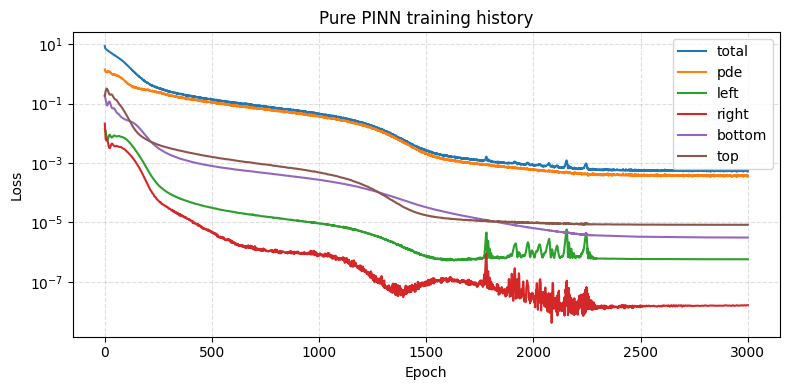

In [11]:
plt.figure(figsize=(8, 4))
plt.semilogy(history["epoch"], history["total"], label="total")
plt.semilogy(history["epoch"], history["pde"], label="pde")
plt.semilogy(history["epoch"], history["left"], label="left")
plt.semilogy(history["epoch"], history["right"], label="right")
plt.semilogy(history["epoch"], history["bottom"], label="bottom")
plt.semilogy(history["epoch"], history["top"], label="top")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pure PINN training history")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# ---------------------------------------------------------------------
# L2 errors for p and q against the manufactured exact solution
# ---------------------------------------------------------------------
def predict_p_numpy(points, batch_size=65536):
    points = np.asarray(points, dtype=np.float64)
    points_t = torch.as_tensor(points, dtype=torch.float32, device=device)
    chunks = []
    p_pinn_net.eval()
    with torch.no_grad():
        for start in range(0, points_t.shape[0], batch_size):
            pred = p_pinn_net(points_t[start:start + batch_size])
            chunks.append(pred.detach().cpu().numpy())
    return np.vstack(chunks)[:, 0]


def predict_q_numpy(points, batch_size=4096):
    points = np.asarray(points, dtype=np.float64)
    points_t = torch.as_tensor(points, dtype=torch.float32, device=device)
    chunks = []
    p_pinn_net.eval()
    for start in range(0, points_t.shape[0], batch_size):
        batch = points_t[start:start + batch_size].detach().clone().requires_grad_(True)
        p_pred = p_pinn_net(batch)
        grad_p = torch.autograd.grad(p_pred.sum(), batch)[0]
        q_pred = -kappa_torch(batch) * grad_p
        chunks.append(q_pred.detach().cpu().numpy())
    return np.vstack(chunks)


def compute_l2_errors(degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants()

    X_cell = map_reference_points_to_physical(X_ref)
    X_flat = X_cell.reshape(-1, gdim)

    p_exact_cell = exact_p_numpy(X_flat).reshape(num_cells, len(X_ref))
    q_exact_cell = exact_q_numpy(X_flat).reshape(num_cells, len(X_ref), gdim)
    p_pinn_cell = predict_p_numpy(X_flat).reshape(num_cells, len(X_ref))
    q_pinn_cell = predict_q_numpy(X_flat).reshape(num_cells, len(X_ref), gdim)

    p_sq = (p_pinn_cell - p_exact_cell) ** 2
    q_sq = np.sum((q_pinn_cell - q_exact_cell) ** 2, axis=2)

    p_err_sq_local = float(np.sum(detJ * (p_sq @ weights)))
    q_err_sq_local = float(np.sum(detJ * (q_sq @ weights)))
    p_err_sq = omega.comm.allreduce(p_err_sq_local, op=MPI.SUM)
    q_err_sq = omega.comm.allreduce(q_err_sq_local, op=MPI.SUM)

    return {
        "p_L2": math.sqrt(p_err_sq),
        "q_L2": math.sqrt(q_err_sq),
    }


l2_errors = compute_l2_errors(degree=error_quadrature_degree)
if MPI.COMM_WORLD.rank == 0:
    print(f"||p_PINN - p_exact||_L2 = {l2_errors['p_L2']:.6e}")
    print(f"||q_PINN - q_exact||_L2 = {l2_errors['q_L2']:.6e}")


||p_PINN - p_exact||_L2 = 8.572939e-04
||q_PINN - q_exact||_L2 = 2.820890e-03


Pure PINN LCE stats: {'max_abs': 2.0660489729043433e-05, 'mean_abs': 1.6589799924289927e-06, 'rms': 2.3565228071690983e-06}


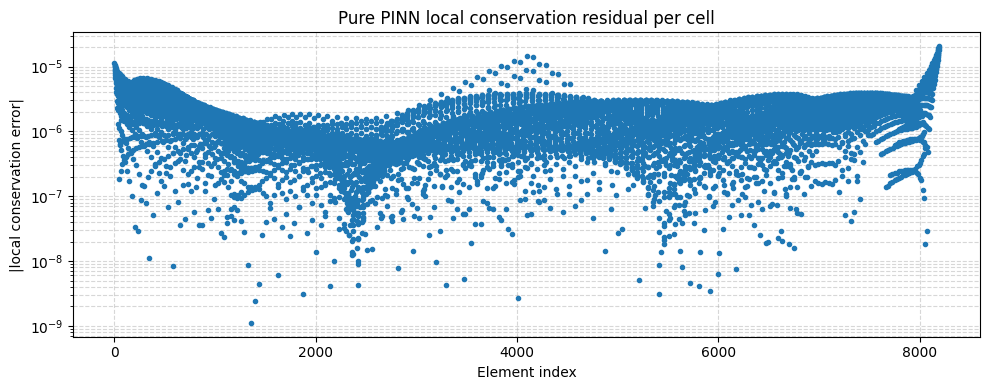

In [13]:
# ---------------------------------------------------------------------
# Local conservation residual per cell
# ---------------------------------------------------------------------
def integrate_source_per_cell(degree=4):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    X_cell = map_reference_points_to_physical(X_ref)
    f_cell = source_numpy(X_cell.reshape(-1, gdim)).reshape(num_cells, len(X_ref))
    detJ = cell_jacobian_determinants()
    return detJ * (f_cell @ weights)


def integrate_boundary_flux_per_cell(q_values, edge_ids, edge_weights, normals, lengths):
    flux_integral = np.zeros(num_cells, dtype=np.float64)
    for edge_id in range(3):
        mask = edge_ids == edge_id
        q_edge = q_values[:, mask, :]
        normal_edge = normals[:, edge_id, :]
        dot_values = np.einsum("cqg,cg->cq", q_edge, normal_edge)
        flux_integral += lengths[:, edge_id] * (dot_values @ edge_weights[mask])
    return flux_integral


def compute_local_conservation_errors(points_per_edge=6, source_degree=4):
    X_ref_edge, edge_ids, edge_weights = reference_triangle_edge_quadrature(points_per_edge)
    normals, lengths = cell_edge_normals_and_lengths()
    int_f = integrate_source_per_cell(source_degree)

    X_edge_cell = map_reference_points_to_physical(X_ref_edge)
    q_pinn_edge = predict_q_numpy(X_edge_cell.reshape(-1, gdim)).reshape(num_cells, len(X_ref_edge), gdim)
    int_q_pinn = integrate_boundary_flux_per_cell(q_pinn_edge, edge_ids, edge_weights, normals, lengths)

    return {
        "lce_pinn": int_q_pinn - int_f,
        "int_q_pinn": int_q_pinn,
        "int_f": int_f,
    }


def lce_stats(values):
    values = np.asarray(values, dtype=np.float64)
    return {
        "max_abs": float(np.max(np.abs(values))),
        "mean_abs": float(np.mean(np.abs(values))),
        "rms": float(np.sqrt(np.mean(values ** 2))),
    }


lce_results = compute_local_conservation_errors(
    points_per_edge=conservation_points_per_edge,
    source_degree=source_quadrature_degree,
)
pinn_lce_stats = lce_stats(lce_results["lce_pinn"])

if MPI.COMM_WORLD.rank == 0:
    print("Pure PINN LCE stats:", pinn_lce_stats)

plt.figure(figsize=(10, 4))
plt.plot(np.abs(lce_results["lce_pinn"]), ".")
plt.yscale("log")
plt.xlabel("Element index")
plt.ylabel("|local conservation error|")
plt.title("Pure PINN local conservation residual per cell")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [14]:
# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------
if MPI.COMM_WORLD.rank == 0:
    print("=" * 72)
    print(f"  Pure PINN - Darcy 2D, no fracture, ref={ref}")
    print("=" * 72)
    print(f"  h                        = {h:.6e}")
    print(f"  Cells                    = {num_cells:,}")
    print(f"  PDE collocation points   = {X_pde.shape[0]:,}")
    print(f"  Unique PDE points        = {rounded_unique_count(X_pde):,}")
    print(f"  Left boundary points     = {X_left.shape[0]:,}")
    print(f"  Right boundary points    = {X_right.shape[0]:,}")
    print(f"  Bottom boundary points   = {X_bottom.shape[0]:,}")
    print(f"  Top boundary points      = {X_top.shape[0]:,}")
    print(f"  PINN parameters          = {num_parameters:,}")
    print(f"  Collocation build time   = {pure_pinn_timings['collocation_build']:.6f} s")
    print(f"  Training time            = {pure_pinn_timings['training']:.6f} s")
    print(f"  Total pure PINN time     = {pure_pinn_timings['total']:.6f} s")
    print(f"  ||p_PINN - p_exact||_L2  = {l2_errors['p_L2']:.6e}")
    print(f"  ||q_PINN - q_exact||_L2  = {l2_errors['q_L2']:.6e}")
    print(f"  max  |R_i| (local cons.) = {pinn_lce_stats['max_abs']:.6e}")
    print(f"  mean |R_i| (local cons.) = {pinn_lce_stats['mean_abs']:.6e}")
    print("=" * 72)


  Pure PINN - Darcy 2D, no fracture, ref=6
  h                        = 1.562500e-02
  Cells                    = 8,192
  PDE collocation points   = 57,344
  Unique PDE points        = 33,024
  Left boundary points     = 128
  Right boundary points    = 128
  Bottom boundary points   = 128
  Top boundary points      = 128
  PINN parameters          = 337
  Collocation build time   = 0.042132 s
  Training time            = 58.132541 s
  Total pure PINN time     = 58.174673 s
  ||p_PINN - p_exact||_L2  = 8.572939e-04
  ||q_PINN - q_exact||_L2  = 2.820890e-03
  max  |R_i| (local cons.) = 2.066049e-05
  mean |R_i| (local cons.) = 1.658980e-06
